In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


import warnings
warnings.filterwarnings('ignore')


from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [5]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [29]:
x = df.drop(columns=['math_score'])
y = df['math_score']

In [30]:
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [31]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [32]:
num_features = x.select_dtypes(exclude='object').columns
cat_features = x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('standard_scaler', numeric_transformer, num_features),
        ('one_hot_encoder', categorical_transformer, cat_features)
    ]
)

In [33]:
x = preprocessor.fit_transform(x)
x

array([[ 0.19399858,  0.39149181,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 1.42747598,  1.31326868,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.77010859,  1.64247471,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 0.12547206, -0.20107904,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.60515772,  0.58901542,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.15336989,  1.18158627,  1.        , ...,  0.        ,
         0.        ,  1.        ]])

In [35]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [36]:
def evaluate_model(true, predicted):
    mse = mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    mae = mean_absolute_error(true, predicted)
    return mse, r2, mae

In [37]:
models = {
    'linear regression': LinearRegression(),
    'lasso': Lasso(),
    'ridge': Ridge(),
    'knn': KNeighborsRegressor(),
    'decision tree': DecisionTreeRegressor(),
    'random forest': RandomForestRegressor(),
    'xgboost': XGBRegressor(),
    'catboost': CatBoostRegressor(verbose=False),
    'adaboost': AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mse, model_train_r2, model_train_mae = evaluate_model(y_train, y_train_pred)
    model_test_mse, model_test_r2, model_test_mae = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('model performance on training set')
    print('mean squared error: {:.4f}'.format(model_train_mse))
    print('r2 score: {:.4f}'.format(model_train_r2))
    print('mean absolute error: {:.4f}'.format(model_train_mae))

    print('--------------------------')

    print('model performance on test set')
    print('mean squared error: {:.4f}'.format(model_test_mse))
    print('r2 score: {:.4f}'.format(model_test_r2))
    print('mean absolute error: {:.4f}'.format(model_test_mae))

    r2_list.append(model_test_r2)
    print('\n\n')

linear regression
model performance on training set
mean squared error: 28.3349
r2 score: 0.8743
mean absolute error: 4.2667
--------------------------
model performance on test set
mean squared error: 29.0952
r2 score: 0.8804
mean absolute error: 4.2148



lasso
model performance on training set
mean squared error: 43.4783
r2 score: 0.8071
mean absolute error: 5.2063
--------------------------
model performance on test set
mean squared error: 42.5063
r2 score: 0.8253
mean absolute error: 5.1579



ridge
model performance on training set
mean squared error: 28.3378
r2 score: 0.8743
mean absolute error: 4.2650
--------------------------
model performance on test set
mean squared error: 29.0563
r2 score: 0.8806
mean absolute error: 4.2111



knn
model performance on training set
mean squared error: 32.6355
r2 score: 0.8552
mean absolute error: 4.5168
--------------------------
model performance on test set
mean squared error: 52.6170
r2 score: 0.7838
mean absolute error: 5.6190



decisi

In [ ]:
pd.DataFrame({'model': model_list, 'r2_score': r2_list}).sort_values(by='r2_score', ascending=False)    

,model,r2_score
2,ridge,0.880593
0,linear regression,0.880433
5,random forest,0.855294
7,catboost,0.851632
8,adaboost,0.847214
1,lasso,0.825320
6,xgboost,0.821221
3,knn,0.783770
4,decision tree,0.758505


LINEAR REGRESSION

In [41]:
Lin_model = LinearRegression()
Lin_model.fit(x_train, y_train)
y_pred = Lin_model.predict(x_test)
score = r2_score(y_test, y_pred)
print('accuracy score of linear regression model is: {:.4f}'.format(score))

accuracy score of linear regression model is: 0.8804


Text(0, 0.5, 'Predictions')

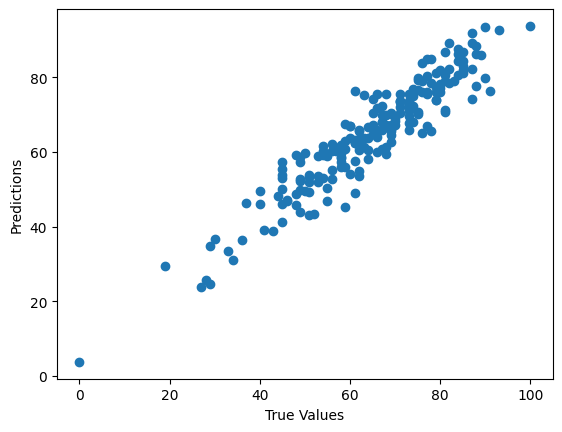

In [42]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')

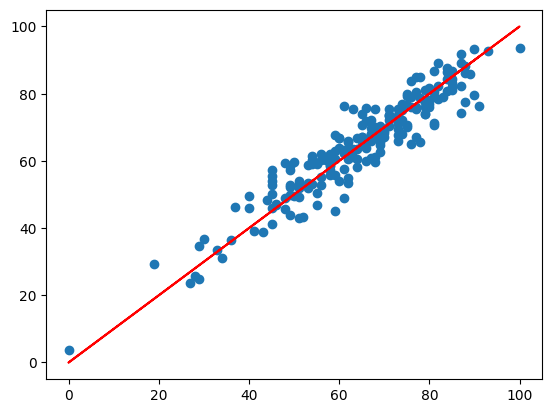

In [44]:
plt.scatter(y_test, y_pred)
plt.plot(y_test, y_test, color='red')

In [46]:
pred_df = pd.DataFrame({'true_values': y_test, 'predicted_values': y_pred,'difference': y_test-y_pred})
pred_df

,true_values,predicted_values,difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
